/root/.cache/scverse_tutorials/daed68867bebbfc19c74265fbab819a0-scverse-getting-started-anndata-pbmc3k_processed.h5ad
[0.6496621 0.6496621 1.0402015 0.6496621 0.6496621 0.6496621 0.6496621
 3.6509345 0.6496621 0.6496621 1.0402015 1.7181969 0.6496621 0.6496621
 0.6496621 0.6496621 0.6496621 0.6496621 1.0402015 0.6496621]
[ 19  52  58 118 131 146 147 180 181 182 208 210 263 270 291 313 324 336
 357 362]
0.068420527186156
normalizing counts per cell
    finished (0:00:00)
Layers with keys: raw, counts_per_million


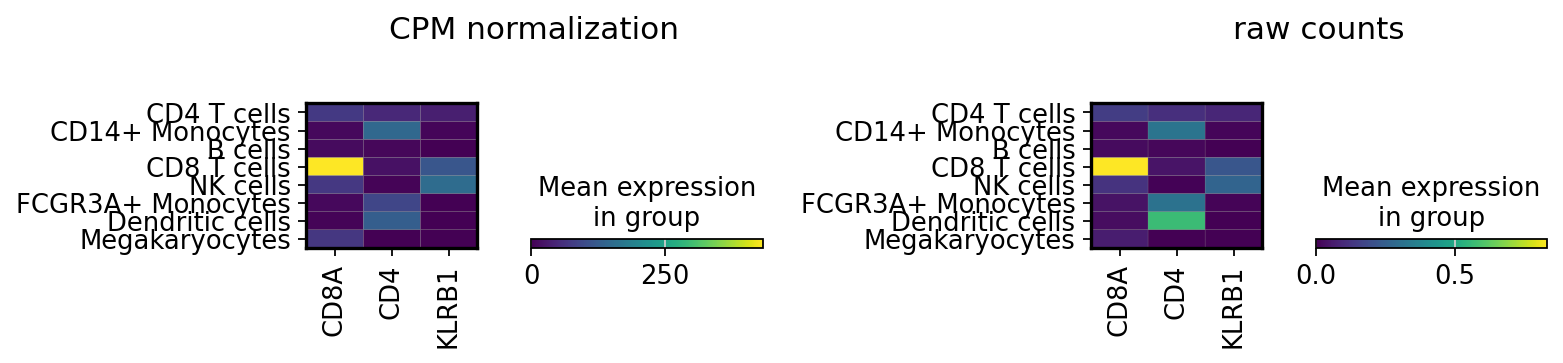

342
X_pca	(2638, 50)
X_tsne	(2638, 2)
X_umap	(2638, 2)


<Figure size 960x320 with 0 Axes>

<Figure size 960x320 with 0 Axes>

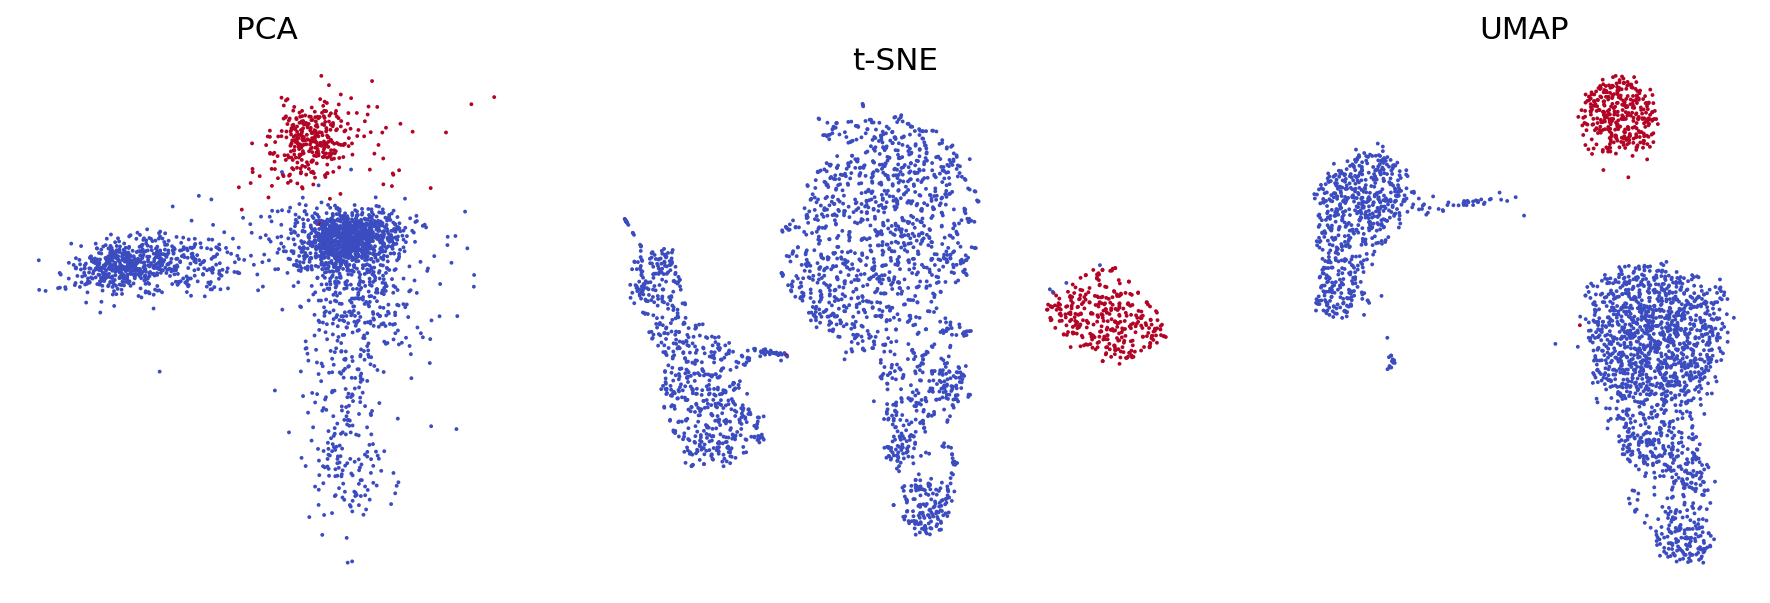

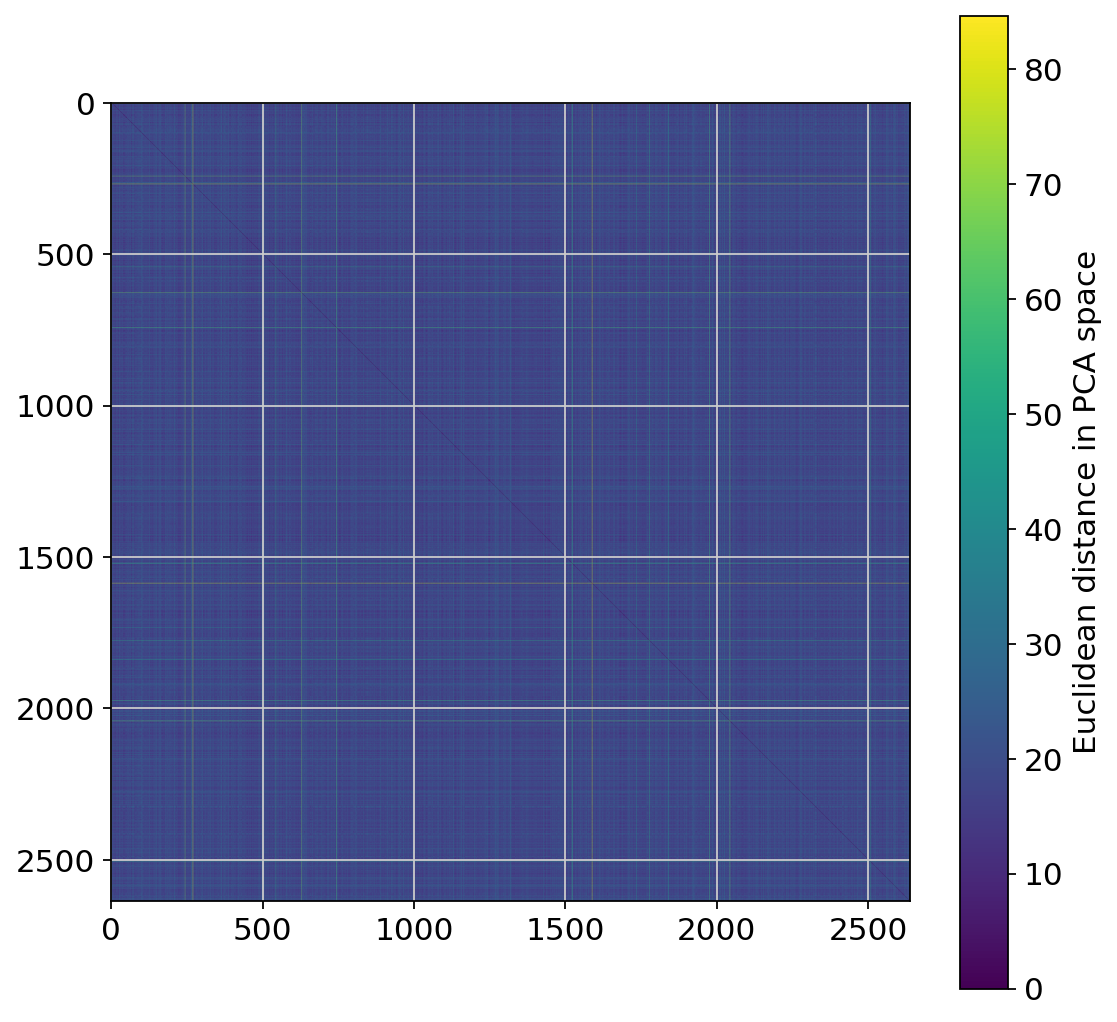

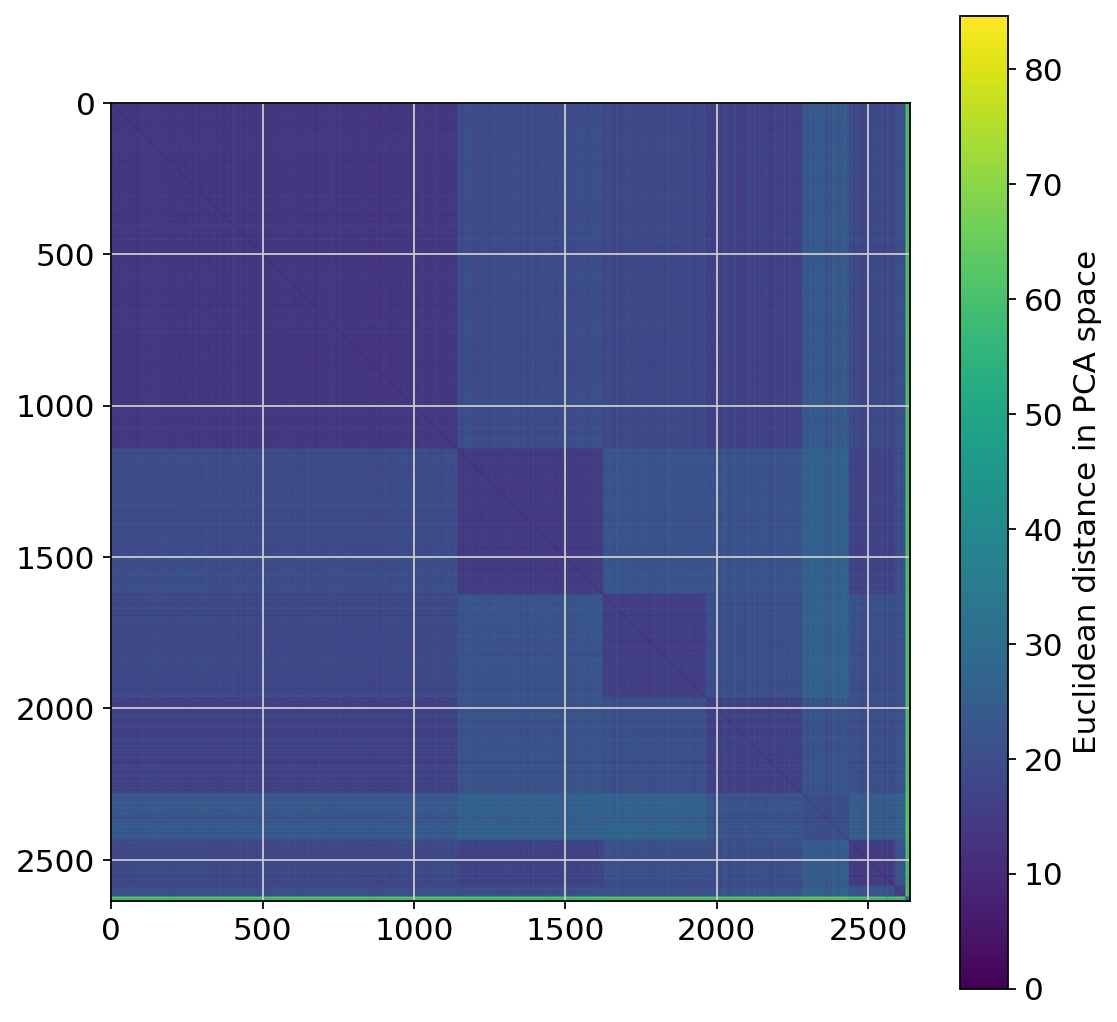

{'params': {'random_state': array([0]), 'resolution': array([1])}}
['#1f77b4' '#ff7f0e' '#2ca02c' '#d62728' '#9467bd' '#8c564b' '#e377c2'
 '#bcbd22']
{'variance': array([32.11044  , 18.718647 , 15.607319 , 13.235274 ,  4.8012376,
        3.977329 ,  3.5053132,  3.1576602,  3.028463 ,  2.9777625,
        2.8842385,  2.8583548,  2.849085 ,  2.8220255,  2.811057 ,
        2.781576 ,  2.7436602,  2.7404478,  2.736062 ,  2.6872916,
        2.671316 ,  2.6690092,  2.6442325,  2.6394093,  2.6157827,
        2.6102393,  2.575101 ,  2.5691617,  2.563295 ,  2.5489197,
        2.5080354,  2.4762378,  2.264355 ,  2.1844513,  2.1353922,
        2.096509 ,  2.0606086,  2.0105643,  1.9703175,  1.9465197,
        1.9220033,  1.8847997,  1.8349565,  1.8038161,  1.7930729,
        1.7611799,  1.7322571,  1.721284 ,  1.6937429,  1.6519767],
      dtype=float32), 'variance_ratio': array([0.02012818, 0.01173364, 0.00978333, 0.00829643, 0.00300962,
       0.00249316, 0.00219728, 0.00197936, 0.00189837, 0.00

/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
/tmp/ipykernel_8435/606658665.py:196: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_view.obs["new_column"] = "Test"
/usr/local/lib/python3.12/dist-packages/scipy/sparse/_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


In [27]:
# Install required packages
!pip install -q anndata scanpy pooch matplotlib numpy scipy pandas
# Import packages
import anndata
import matplotlib.pyplot as plt
import numpy as np
import pooch
import scanpy as sc

# Download the example PBMC AnnData file automatically
datapath = pooch.retrieve(
    path=pooch.os_cache("scverse_tutorials"),
    url="https://exampledata.scverse.org/tutorials/scverse-getting-started-anndata-pbmc3k_processed.h5ad",
    known_hash="md5:b80deb0997f96b45d06f19c694e46243",
)

print(datapath)

# Read the file into an AnnData object
adata = anndata.read_h5ad(datapath)

# Show summary
adata

# View the active data matrix
adata.X

# Non-zero values
print(adata.X.data[:20])

# Column indices of non-zero values
print(adata.X.indices[:20])

# Fraction of non-zero entries
print(adata.X.nnz / np.prod(adata.X.shape))

# Check available layers
adata.layers

# View raw counts layer
adata.layers["raw"]

# Inspect raw counts values
adata.layers["raw"].data[:20]

# Copy raw counts into a new layer
adata.layers["counts_per_million"] = adata.layers["raw"].copy()

# Normalize this new layer to counts per million
sc.pp.normalize_total(adata, target_sum=10**6, layer="counts_per_million")

# Confirm layers
print(adata.layers)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 2.5))

genes_of_interest = ["CD8A", "CD4", "KLRB1"]

sc.pl.matrixplot(
    adata,
    groupby="louvain_cell_types",
    var_names=genes_of_interest,
    layer="counts_per_million",
    ax=ax1,
    show=False,
)
ax1.set_title("CPM normalization")

sc.pl.matrixplot(
    adata,
    groupby="louvain_cell_types",
    var_names=genes_of_interest,
    layer="raw",
    ax=ax2,
    show=False,
)
ax2.set_title("raw counts")

plt.tight_layout()
plt.show()

# View obs table
adata.obs

# Show column names
adata.obs.keys()

# Access one annotation column
adata.obs["louvain_cell_types"]

print(sum(adata.obs["louvain_cell_types"] == "B cells"))

adata.obs["is_low_quality"] = adata.obs["percent_mito"] > 0.03
adata.obs.head()

adata.var

adata.obs_names
adata.var_names
adata.var_names = adata.var["gene_ids"]
adata.var.head()
adata.var_names = adata.var["gene_names"]
adata.var.head()

adata_small = adata[:5, ["LYZ", "FOS", "MALAT1"]]
adata_small.shape
# Active matrix
adata_small.X.toarray()
# Raw layer
adata_small.layers["raw"].toarray()
# Cell annotations
adata_small.obs
# Gene annotations
adata_small.var

adata_high_quality = adata[~adata.obs["is_low_quality"], :]
adata_high_quality.obs

adata.obsm
for key in adata.obsm:
    print(key, adata.obsm[key].shape, sep="\t")

    plt.figure(figsize=(12, 4))

# PCA
plt.subplot(1, 3, 1)
plt.scatter(
    x=adata.obsm["X_pca"][:, 0],
    y=adata.obsm["X_pca"][:, 1],
    c=adata.obs["louvain_cell_types"] == "B cells",
    s=3,
    linewidth=0,
    cmap="coolwarm",
)
plt.title("PCA")
plt.axis("off")
plt.gca().set_aspect("equal")

# t-SNE
plt.subplot(1, 3, 2)
plt.scatter(
    x=adata.obsm["X_tsne"][:, 0],
    y=adata.obsm["X_tsne"][:, 1],
    c=adata.obs["louvain_cell_types"] == "B cells",
    s=3,
    linewidth=0,
    cmap="coolwarm",
)
plt.title("t-SNE")
plt.axis("off")
plt.gca().set_aspect("equal")

# UMAP
plt.subplot(1, 3, 3)
plt.scatter(
    x=adata.obsm["X_umap"][:, 0],
    y=adata.obsm["X_umap"][:, 1],
    c=adata.obs["louvain_cell_types"] == "B cells",
    s=3,
    linewidth=0,
    cmap="coolwarm",
)
plt.title("UMAP")
plt.axis("off")
plt.gca().set_aspect("equal")

plt.tight_layout()
plt.show()

adata.obsp
adata.obsp["distances_all"]
plt.imshow(adata.obsp["distances_all"])
plt.colorbar(label="Euclidean distance in PCA space")
plt.show()

reorder_by_celltype = np.argsort(adata.obs["louvain_cell_types"])

plt.imshow(adata[reorder_by_celltype, :].obsp["distances_all"])
plt.colorbar(label="Euclidean distance in PCA space")
plt.show()

adata.uns.keys()
print(adata.uns["louvain"])
print(adata.uns["louvain_colors"])
print(adata.uns["pca"])

adata.X[:5, 5:10].toarray()
adata_view = adata[:5, 5:10]
adata_view
adata_view.X.toarray()
adata.X[0, 7] = 99
adata_view.X.toarray()

adata_view_copy = adata_view.copy()
adata_view_copy
adata_view.obs["new_column"] = "Test"
adata_view
adata.X[0, 8] = 98

print("Parent:")
print(adata.X[:5, 5:10].toarray())

print("\nFormer view:")
print(adata_view.X.toarray())

print("\nCopied object:")
print(adata_view_copy.X.toarray())